In [1]:
import xarray as xr
import numpy as np
from scipy.ndimage import binary_erosion, binary_dilation
from tqdm import tqdm
import matplotlib.pyplot as plt

In [2]:
# mask
def coastal_band_mask(ds, var='u10', iterations=10):
    """
    Create a coastal band mask by dilating the coastline edge.

    Parameters
    ----------
    ds : xr.Dataset
        Must contain 2D lat/lon coords and the target variable.
    var : str
        Variable name used to detect land (NaN) vs ocean.
    iterations : int
        Number of dilation steps (~10 km per iteration on a ~10 km grid).

    Returns
    -------
    da_mask : xr.DataArray
        Boolean mask (True inside the coastal band).
    """
    valid2d = np.isfinite(ds[var].mean(dim='time')).values.astype(bool)

    eroded = binary_erosion(valid2d, structure=np.ones((3, 3)), iterations=1)
    coast = valid2d & (~eroded)

    band = binary_dilation(coast, structure=np.ones((3, 3)), iterations=iterations) & valid2d

    da_mask = xr.DataArray(
        band,
        dims=('lat', 'lon'),
        coords={'lat': ds['lat'], 'lon': ds['lon']},
    )
    return da_mask


In [3]:
# ============================================================
# 2. Load data and apply mask
# ============================================================
ds = xr.open_dataset('winds_and_components_corrected.nc')
mask = coastal_band_mask(ds, var='Uek_geo', iterations=10)  # ~111 km cross-shore
wind_coastal = ds.where(mask).sel(lon=slice(-85, None), lat=slice(-20, -4))

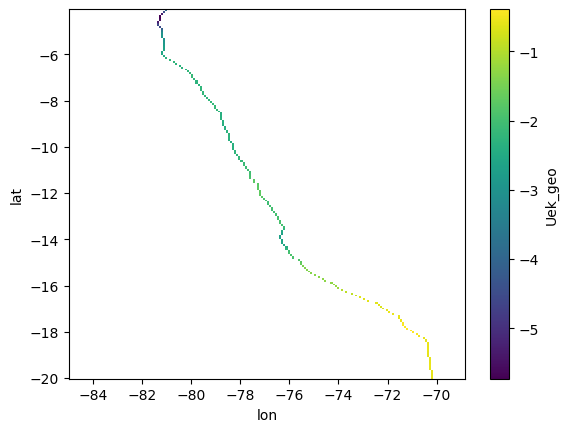

In [4]:
valid = np.isfinite(wind_coastal.Uek_geo.isel(time=0))
valid_e = valid.shift(lon=-1).fillna(False).astype(bool)
coast_mask = valid & (~valid_e)
# ssh_coast = ssh.SSH.where(coast_mask)

wind_coastal.Uek_geo.where(coast_mask).mean('time').plot()

In [5]:
# ============================================================
# 3. Find coastal and offshore boundary longitudes per latitude
# ============================================================
valid = np.isfinite(wind_coastal.Uek_geo.isel(time=0))
valid_e = valid.shift(lon=-1).fillna(False).astype(bool)
valid_w = valid.shift(lon=+1).fillna(False).astype(bool)

coast_mask = valid & (~valid_e)      # easternmost valid cell (coast)
offshore_mask = valid & (~valid_w)   # westernmost valid cell (offshore edge)

lat_all = wind_coastal.lat.values
lon_all = wind_coastal.lon.values

coast_lons = np.full(len(lat_all), np.nan)
offshore_lons = np.full(len(lat_all), np.nan)

for j in range(len(lat_all)):
    cols_e = np.where(coast_mask.isel(lat=j).values)[0]
    if len(cols_e) > 0:
        coast_lons[j] = lon_all[cols_e[0]]
    cols_w = np.where(offshore_mask.isel(lat=j).values)[0]
    if len(cols_w) > 0:
        offshore_lons[j] = lon_all[cols_w[0]]

Text(0.5, 1.0, 'coast / offshore boundary detection')

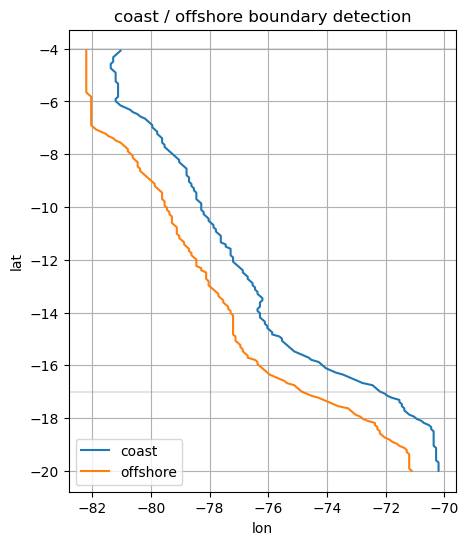

In [6]:
# Coastline diagnostic — verify coast_lons/offshore_lons look smooth.
# Jumps in coast_lons (from islands, bays, masked pixels) were the
# cause of the earlier inflated d_coast in bands 2, 11, 12.
fig, ax = plt.subplots(figsize=(5, 6))
ax.plot(coast_lons, lat_all, label='coast')
ax.plot(offshore_lons, lat_all, label='offshore')
ax.set_xlabel('lon'); ax.set_ylabel('lat')
ax.axhline(-4,  color='grey', lw=0.3)
ax.axhline(-17, color='grey', lw=0.3)
ax.legend(); ax.grid(True)
ax.set_title('coast / offshore boundary detection')

In [7]:
# def haversine(lat1, lon1, lat2, lon2):
#     R = 6371000.0
#     lat1_r, lat2_r = np.deg2rad(lat1), np.deg2rad(lat2)
#     dlat = np.deg2rad(lat2 - lat1)
#     dlon = np.deg2rad(lon2 - lon1)
#     a = np.sin(dlat/2)**2 + np.cos(lat1_r)*np.cos(lat2_r)*np.sin(dlon/2)**2
#     return R * 2 * np.arcsin(np.sqrt(a))

def haversine(lat1, lon1, lat2, lon2):
    R = 6371000.0
    lat1_rad = np.deg2rad(lat1)
    lon1_rad = np.deg2rad(lon1)
    lat2_rad = np.deg2rad(lat2)
    lon2_rad = np.deg2rad(lon2)
    delta_lat = lat2_rad - lat1_rad
    delta_lon = lon2_rad - lon1_rad
    a = (np.sin(delta_lat / 2.0) ** 2
         + np.cos(lat1_rad) * np.cos(lat2_rad) * np.sin(delta_lon / 2.0) ** 2)
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

In [8]:
uek_coast = wind_coastal.Uek_geo.where(coast_mask) 
UEK_band = uek_coast.mean('lon').sel(lat=slice(-17, -5))
# Real distance using both lat AND lon of coastal points
lat_s = UEK_band.lat.values[0]
lat_n = UEK_band.lat.values[-1]

# Find the coastal lon at the south and north edges
idx_s = np.abs(lat_all - lat_s).argmin()
idx_n = np.abs(lat_all - lat_n).argmin()
lon_s = coast_lons[idx_s]
lon_n = coast_lons[idx_n]

d_coast = haversine(lat_s, lon_s, lat_n, lon_n)
# d_coast_list.append(d_)
d_coast/1000

1648.2563417570939

In [9]:
# ============================================================
# 4. qdiv function — returns m²/s
# ============================================================
def coast_path_length(lat_south, lat_north, all_lats, coast_lons):
    """Cumulative along-coast distance by summing haversine between
    consecutive coastal cells inside the band. Robust to coastline
    curvature and endpoint noise."""
    band_idx = np.where((all_lats >= lat_south) & (all_lats <= lat_north))[0]
    pts = [(all_lats[j], coast_lons[j]) for j in band_idx
           if np.isfinite(coast_lons[j])]
    if len(pts) < 2:
        return np.nan
    d = 0.0
    for (la1, lo1), (la2, lo2) in zip(pts[:-1], pts[1:]):
        d += haversine(la1, lo1, la2, lo2)
    return d


def qdiv_for_band(Uek, Vek,
                  lat_south, lat_north,
                  offshore_lons, coast_lons, all_lats):

    A = 6371000.0

    Uek_ = Uek.sel(lat=slice(lat_south, lat_north))
    Vek_ = Vek.sel(lat=slice(lat_south, lat_north))

    lat_vals = Uek_.lat.values
    lon_vals = Uek_.lon.values
    mean_lat = np.mean(lat_vals)

    # Cumulative along-coast length (sums all intermediate coastal cells
    # rather than just the band endpoints — avoids spurious inflation
    # when coastline bends or endpoint detection is noisy).
    d_coast = coast_path_length(lat_south, lat_north, all_lats, coast_lons)

    # Build 2D strip mask following coast/offshore boundaries per row
    band_idx = np.where((all_lats >= lat_south) & (all_lats <= lat_north))[0]
    strip_mask = np.zeros((len(lat_vals), len(lon_vals)), dtype=bool)

    for j, idx in enumerate(band_idx):
        if j >= len(lat_vals):
            break
        lw = offshore_lons[idx]
        le = coast_lons[idx]
        if np.isfinite(lw) and np.isfinite(le):
            strip_mask[j, :] = (lon_vals >= lw) & (lon_vals <= le)

    # Apply strip mask
    strip_da = xr.DataArray(strip_mask, dims=('lat', 'lon'),
                            coords={'lat': lat_vals, 'lon': lon_vals})
    Uek_ = Uek_.where(strip_da)
    Vek_ = Vek_.where(strip_da)

    # Grid spacing for face integration
    dy_mean = A * np.deg2rad(np.abs(np.diff(lat_vals))).mean()
    dx_mean = A * np.cos(np.deg2rad(mean_lat)) * np.deg2rad(np.abs(np.diff(lon_vals))).mean()

    # Boundary detection
    valid_da = xr.where(np.isfinite(Uek_), 1, 0)
    valid_e = valid_da.shift(lon=-1)
    valid_w = valid_da.shift(lon=+1)
    west_mask = (valid_da == 1) & (valid_w == 0)
    east_mask = (valid_da == 1) & (valid_e == 0)

    easternmost_u  = Uek_.where(east_mask)    
    westernmost_u  = Uek_.where(west_mask)
 
    easternmost_v = Vek_.where(east_mask)
    westernmost_v = Vek_.where(west_mask)
    
    southernmost = Vek_.isel(lat=0)
    northernmost = Vek_.isel(lat=-1)

    # Volume fluxes through each face (m³/s)
    QE = (easternmost_u.mean('lon')
          .rolling(lat=2, center=False)
          .mean(skipna=True).sum(dim='lat') * dy_mean)
    
    QW_u = -(westernmost_u.mean('lon')
           .rolling(lat=2, center=False)
           .mean(skipna=True).sum(dim='lat') * dy_mean) 
    
    QW_v = - (westernmost_v.mean('lon')
           .rolling(lat=2, center=False)
           .mean(skipna=True).sum(dim='lat') * dy_mean) 

    QN = (northernmost
          .rolling(lon=2, center=False)
          .mean(skipna=True).sum(dim='lon') * dx_mean)
    QS = -(southernmost
           .rolling(lon=2, center=False)
           .mean(skipna=True).sum(dim='lon') * dx_mean)
    
    # Normalize by alongshore length → m²/s
    Qdiv = (QW_u + QW_v + QS + QN)/d_coast

    return Qdiv,d_coast,QW_u/d_coast,QW_v/d_coast,QS/d_coast,QN/d_coast, QE/d_coast

In [10]:
def lat_band_mean(
    f,
    lat_top_start=-4,
    lat_top_end=-17,
):
    """
    Compute the mean of f for successive 1° latitude bands.

    Parameters
    ----------
    f : xarray.DataArray
        Must have a 'lat' dimension (and optionally time/lon/etc.).
    lat_top_start : float or int
        Northern latitude of the first band (e.g. -5).
    lat_top_end : float or int
        Northern latitude of the last band (e.g. -16).

    Returns
    -------
    f_band : xarray.DataArray
        Mean of f for each 1° band, with new dimension 'lat_band'.
        Any other original dimensions (e.g. time) are preserved.
    """

    results = []
    lat_band_centers = []

    for lat_north in tqdm(range(lat_top_start, lat_top_end, -1)):
        lat_south = lat_north - 1

        # 1° band slice
        f_band = f.sel(lat=slice(lat_south, lat_north))

        # skip bands with no points
        if f_band.sizes.get("lat", 0) == 0:
            continue

        results.append(f_band.mean(dim='lat'))
        lat_band_centers.append(0.5 * (lat_south + lat_north))

    # concat over bands
    f_out = xr.concat(results, dim="lat_band")
    f_out = f_out.assign_coords(lat_band=np.array(lat_band_centers))

    return f_out

In [11]:
# ============================================================
# 5. Loop over latitude bands
# ============================================================
# Qdiv,d_coast,QW,QS,QN
lat_top_start = -4
lat_top_end   = -17

results = []
lat_band_centers = []
d_coast = []
QW_u = []
QW_v = []
QS_ = []
QN_ = []
QE_ = []

for lat_north in tqdm(range(lat_top_start, lat_top_end, -1)):
    lat_south = lat_north - 1
    Qdiv_band,dd,QWu,QWv,QS,QN,QE = qdiv_for_band(
        wind_coastal.Uek_geo, wind_coastal.Vek_geo,
        lat_south=lat_south, lat_north=lat_north,
        offshore_lons=offshore_lons, coast_lons=coast_lons,
        all_lats=lat_all,
    )
    results.append(Qdiv_band)
    lat_band_centers.append(0.5 * (lat_south + lat_north))
    d_coast.append(dd)
    QW_u.append(QWu)
    QW_v.append(QWv)
    QS_.append(QS)
    QN_.append(QN)
    QE_.append(QE)

Qdiv_all = xr.concat(results, dim='lat_band')
QW_u_all = xr.concat(QW_u, dim='lat_band')
QW_v_all = xr.concat(QW_v, dim='lat_band')
QS_all = xr.concat(QS_, dim='lat_band')
QN_all = xr.concat(QN_, dim='lat_band')
QE_all = xr.concat(QE_, dim='lat_band')

U_ek = Qdiv_all.assign_coords(lat_band=lat_band_centers)
QW__u = QW_u_all.assign_coords(lat_band=lat_band_centers) 
QW__v = QW_v_all.assign_coords(lat_band=lat_band_centers) 

QS__ = QS_all.assign_coords(lat_band=lat_band_centers)
QN__ = QN_all.assign_coords(lat_band=lat_band_centers)
QE__ = QE_all.assign_coords(lat_band=lat_band_centers)

100%|████████████████████████████████████████████████████████████████████████████████████| 13/13 [00:00<00:00, 22.22it/s]


In [12]:
d_coast

[124562.36726699636,
 109086.10661761712,
 169670.87512256543,
 127677.24756541123,
 123578.50321153678,
 119449.85148189467,
 122860.52938317883,
 138919.86100024404,
 129472.51415582518,
 117761.6441584467,
 149288.70425897668,
 176473.69088798173,
 234172.44696987938]

Per-band closure check:
  lat_band=-4.5: residual=+5.884e+00 m²/s  (rel=+100.0% of |ΣQ|)
  lat_band=-5.5: residual=+3.538e+00 m²/s  (rel=+100.0% of |ΣQ|)
  lat_band=-6.5: residual=+2.660e+00 m²/s  (rel=+100.0% of |ΣQ|)
  lat_band=-7.5: residual=+2.166e+00 m²/s  (rel=+100.0% of |ΣQ|)
  lat_band=-8.5: residual=+2.556e+00 m²/s  (rel=+100.0% of |ΣQ|)
  lat_band=-9.5: residual=+2.694e+00 m²/s  (rel=+100.0% of |ΣQ|)
  lat_band=-10.5: residual=+2.713e+00 m²/s  (rel=+100.0% of |ΣQ|)
  lat_band=-11.5: residual=+2.088e+00 m²/s  (rel=+100.0% of |ΣQ|)
  lat_band=-12.5: residual=+2.221e+00 m²/s  (rel=+100.0% of |ΣQ|)
  lat_band=-13.5: residual=+2.787e+00 m²/s  (rel=+100.0% of |ΣQ|)
  lat_band=-14.5: residual=+2.858e+00 m²/s  (rel=+100.0% of |ΣQ|)
  lat_band=-15.5: residual=+1.776e+00 m²/s  (rel=+100.0% of |ΣQ|)
  lat_band=-16.5: residual=+9.192e-01 m²/s  (rel=+100.0% of |ΣQ|)


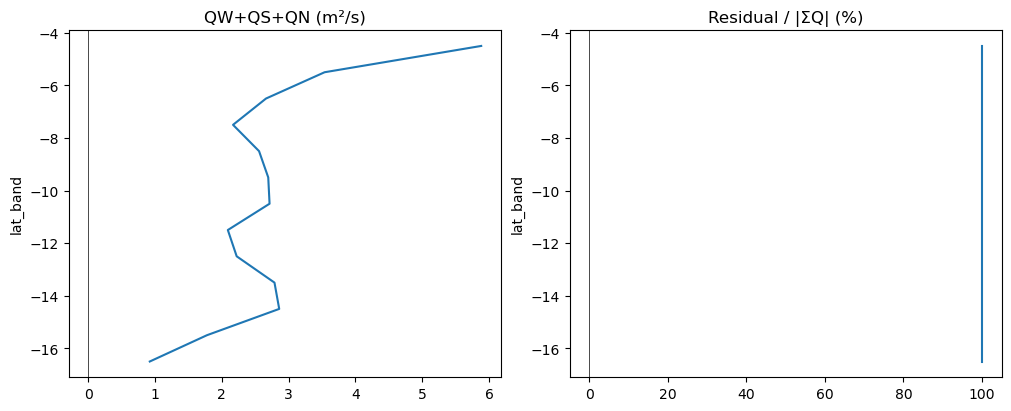

In [13]:
# Mass conservation check: QE + QW + QS + QN should be ≈ 0
# (all flux through the closed box sums to zero for a non-divergent field).
# Deviations indicate either real divergence (pumping into MLD) or numerical
# error in face integration.
residual = (QW__u + QW__v + QS__ + QN__).mean('time')
total    = (QW__u + QW__v + QS__ + QN__).mean('time')
rel = (residual / total)

print("Per-band closure check:")
for lb, r, t in zip(rel.lat_band.values, residual.values, total.values):
    print(f"  lat_band={lb:+.1f}: residual={r:+.3e} m²/s  (rel={r/t*100:+.1f}% of |ΣQ|)")

fig, ax = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
residual.plot(y='lat_band', ax=ax[0])
ax[0].set_title('QW+QS+QN (m²/s)')
ax[0].axvline(0, color='k', lw=0.5)
(rel*100).plot(y='lat_band', ax=ax[1])
ax[1].set_title('Residual / |ΣQ| (%)')
ax[1].axvline(0, color='k', lw=0.5)

In [14]:
# This should show ~100 km difference per row
for j in range(len(lat_all)):
    if np.isfinite(coast_lons[j]) and np.isfinite(offshore_lons[j]):
        diff = np.abs(coast_lons[j] - offshore_lons[j])
        # if diff > 1.5:  # more than ~1.5 degrees = ~150 km
        print(f"lat={lat_all[j]:.1f}: coast={coast_lons[j]:.2f}, offshore={offshore_lons[j]:.2f}, diff={diff:.2f}°")

lat=-20.0: coast=-70.20, offshore=-71.12, diff=0.92°
lat=-19.9: coast=-70.20, offshore=-71.20, diff=1.00°
lat=-19.8: coast=-70.20, offshore=-71.20, diff=1.00°
lat=-19.8: coast=-70.20, offshore=-71.20, diff=1.00°
lat=-19.7: coast=-70.20, offshore=-71.20, diff=1.00°
lat=-19.6: coast=-70.28, offshore=-71.20, diff=0.92°
lat=-19.5: coast=-70.28, offshore=-71.20, diff=0.92°
lat=-19.4: coast=-70.28, offshore=-71.20, diff=0.92°
lat=-19.4: coast=-70.28, offshore=-71.20, diff=0.92°
lat=-19.3: coast=-70.28, offshore=-71.28, diff=1.00°
lat=-19.2: coast=-70.28, offshore=-71.28, diff=1.00°
lat=-19.1: coast=-70.28, offshore=-71.37, diff=1.08°
lat=-19.1: coast=-70.37, offshore=-71.53, diff=1.17°
lat=-19.0: coast=-70.37, offshore=-71.62, diff=1.25°
lat=-18.9: coast=-70.37, offshore=-71.78, diff=1.42°
lat=-18.8: coast=-70.37, offshore=-71.87, diff=1.50°
lat=-18.7: coast=-70.37, offshore=-72.03, diff=1.67°
lat=-18.7: coast=-70.37, offshore=-72.12, diff=1.75°
lat=-18.6: coast=-70.37, offshore=-72.20, diff

In [15]:
widths = []
A = 6371000.0
for j in range(len(lat_all)):
    if np.isfinite(coast_lons[j]) and np.isfinite(offshore_lons[j]):
        w = A * np.cos(np.deg2rad(lat_all[j])) * np.deg2rad(np.abs(coast_lons[j] - offshore_lons[j]))
        widths.append(w)
d_band = np.mean(widths)
print(f"Mean cross-shore width: {d_band/1000:.1f} km")

Mean cross-shore width: 158.5 km


In [16]:
A = 6371000.0
widths = np.full(len(lat_all), np.nan)
for j in range(len(lat_all)):
    if np.isfinite(coast_lons[j]) and np.isfinite(offshore_lons[j]):
        widths[j] = A * np.cos(np.deg2rad(lat_all[j])) * np.deg2rad(np.abs(coast_lons[j] - offshore_lons[j]))

widths_da = xr.DataArray(widths, dims='lat', coords={'lat': lat_all}, name='cross_shore_width')

d = lat_band_mean(widths_da, lat_top_start=-4, lat_top_end=-17)
print(d)

100%|██████████████████████████████████████████████████████████████████████████████████| 13/13 [00:00<00:00, 3278.57it/s]

<xarray.DataArray 'cross_shore_width' (lat_band: 13)> Size: 104B
array([105458.90064369, 110678.49570305, 174124.19664479, 174557.27090506,
       162664.9712667 , 132518.60065302, 135907.15962886, 148076.86426844,
       150001.13607504, 137427.50132693, 126940.96449613, 194912.35870913,
       263755.17819263])
Coordinates:
  * lat_band  (lat_band) float64 104B -4.5 -5.5 -6.5 -7.5 ... -14.5 -15.5 -16.5


In [17]:
d_coast

[124562.36726699636,
 109086.10661761712,
 169670.87512256543,
 127677.24756541123,
 123578.50321153678,
 119449.85148189467,
 122860.52938317883,
 138919.86100024404,
 129472.51415582518,
 117761.6441584467,
 149288.70425897668,
 176473.69088798173,
 234172.44696987938]

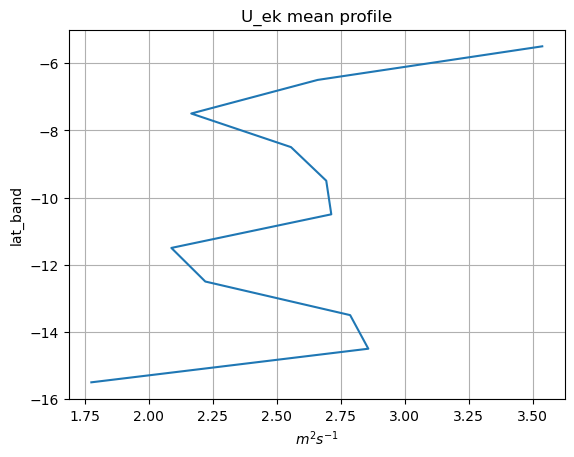

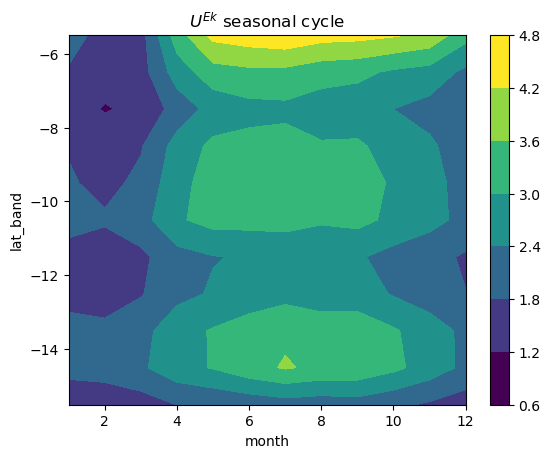

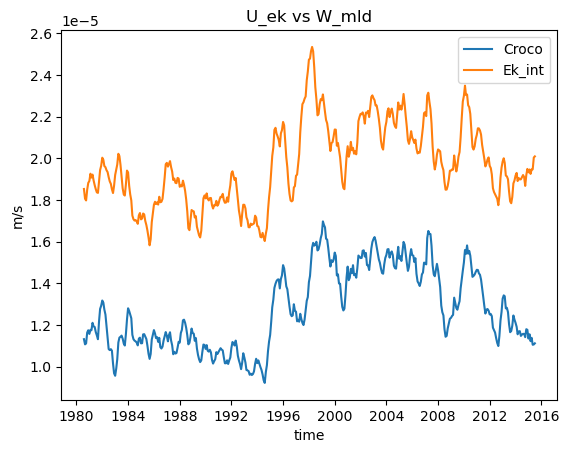

In [18]:
# ============================================================
# 6. Quick checks
# ============================================================

# Seasonality
def seasonality(data):
    return data.groupby('time.month').mean(dim='time')

# Latitudinal mean profile
U_ek.sel(lat_band=slice(-5, -16)).mean('time').rename('$m^{2}s^{-1}$').plot(y='lat_band')
plt.title('U_ek mean profile')
plt.grid(True)
plt.show()

# Seasonal Hovmöller
seasonality(U_ek).sel(lat_band=slice(-5, -16)).plot.contourf(x='month')
plt.title('$U^{Ek}$ seasonal cycle')
plt.show()

# Time series comparison with W_mld
wmld = xr.open_dataset('W_mld_Croco.nc').compute()
wmld = wmld.where(mask).sel(lon=slice(-85, None), lat=slice(-16, -5))

# d = (1/12) * 10 * 111 * 1000  # cross-shore width for m²/s → m/s conversion
# d= 111 * 1000

wmld.mean(dim=('lon', 'lat')).WMLD.rolling(time=13, center=True).mean().rename('m/s').plot(label='Croco')
(U_ek/d).mean(dim='lat_band').rolling(time=13, center=True).mean().rename('m/s').plot(label='Ek_int')
plt.legend()
plt.title('U_ek vs W_mld')
plt.show()

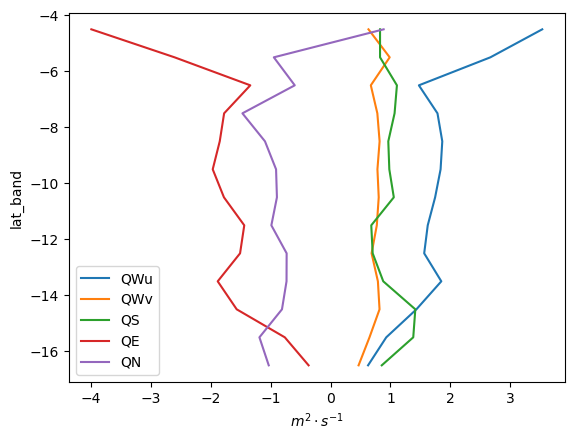

In [19]:
QW__u.mean('time').plot(y='lat_band',label='QWu')
QW__v.mean('time').plot(y='lat_band',label='QWv')

(QS__).mean('time').plot(y='lat_band',label='QS')
QE__.mean('time').plot(y='lat_band',label='QE')
QN__.mean('time').rename('$m^2 \cdot s^{-1}$').plot(y='lat_band',label='QN')

# (QE + QW__ + QS__ + QN__).mean('time').rename('$m^2 \cdot s^{-1}$').plot(y='lat_band',label='Qdiv*')
# (QW__ + QS__ + QN__).mean('time').rename('$m^2 \cdot s^{-1}$').plot(y='lat_band',label='Uekman')
# (QW__ + (QS__*-1) - QN__).mean('time').rename('$m^2 \cdot s^{-1}$').plot(y='lat_band',label='Qdiv*')
plt.legend()

## Now the Geostrophic Velocity

$
u_{\mathrm{geo}} = \frac{g}{f}\,\frac{\Delta \mathrm{SSH}}{d_{\mathrm{coast}}}
$

$
\mathbf{U}_{\mathrm{geo}} = \mathbf{u}_{\mathrm{geo}} \times \mathrm{MLD}
$

In [20]:
ssh = xr.open_dataset('SSH.nc').compute()
ssh

<xarray.Dataset> Size: 564MB
Dimensions:  (time: 432, lat: 542, lon: 602)
Coordinates:
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
  * lat      (lat) float64 4kB -33.0 -32.93 -32.86 -32.79 ... 9.869 9.951 10.03
  * lon      (lon) float64 5kB -119.0 -118.9 -118.8 ... -69.03 -68.95 -68.87
Data variables:
    SSH      (time, lat, lon) float32 564MB 0.212 0.212 0.2117 ... 0.0 0.0 0.0

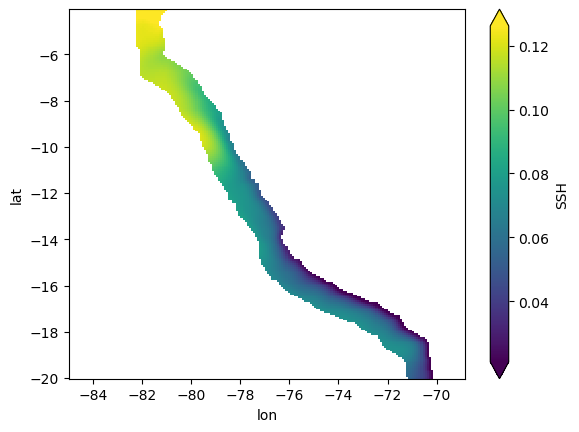

In [21]:
## SSH is in m
ssh = ssh.where(mask).sel(lon=slice(-85,None),lat=slice(-20,-4))
ssh.mean('time').SSH.plot(robust=True)

In [22]:
valid = np.isfinite(ssh.SSH.isel(time=0))
valid_e = valid.shift(lon=-1).fillna(False).astype(bool)
coast_mask = valid & (~valid_e)
ssh_coast = ssh.SSH.where(coast_mask)

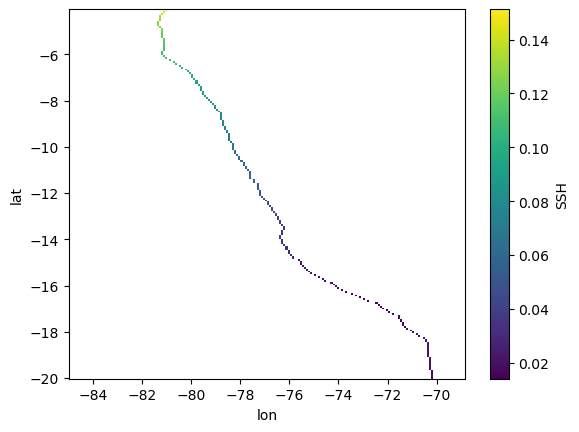

In [23]:
ssh_coast.mean('time').plot()

In [24]:
lat_top_start = -4
lat_top_end   = -17

delta_SSH = []
d_coast_list = []

for lat_north in tqdm(range(lat_top_start, lat_top_end, -1)):
    lat_south = lat_north - 1
    SSH_band = ssh_coast.mean('lon').sel(lat=slice(lat_south, lat_north))

    southernmost = SSH_band.isel(lat=0)
    northernmost = SSH_band.isel(lat=-1)
    delta_SSH.append(northernmost - southernmost)

    # Cumulative along-coast distance (robust to coast curvature)
    d_ = coast_path_length(lat_south, lat_north, lat_all, coast_lons)
    d_coast_list.append(d_)

ssh_ = xr.concat(delta_SSH, dim='lat_band')
ssh_ = ssh_.assign_coords(
    lat_band=np.arange(lat_top_start - 0.5, lat_top_end - 0.5, -1)
)

d_coast_ = xr.DataArray(d_coast_list, dims='lat_band',
                        coords={'lat_band': ssh_.lat_band})

# Sanity check: expect ~111 km plus a small curvature increment
for i, dc in enumerate(d_coast_list):
    lat_only = 6371000 * np.deg2rad(1.0)  # ~111 km
    print(f"Band {i}: d_coast = {dc/1000:.1f} km (vs {lat_only/1000:.1f} km lat-only, {(dc/lat_only-1)*100:+.1f}%)")

# Verify: should be positive on average (SSH increases northward along coast)
print("Mean ssh_ (should be positive):", ssh_.mean().values)

100%|████████████████████████████████████████████████████████████████████████████████████| 13/13 [00:00<00:00, 17.87it/s]

Band 0: d_coast = 124.6 km (vs 111.2 km lat-only, +12.0%)
Band 1: d_coast = 109.1 km (vs 111.2 km lat-only, -1.9%)
Band 2: d_coast = 169.7 km (vs 111.2 km lat-only, +52.6%)
Band 3: d_coast = 127.7 km (vs 111.2 km lat-only, +14.8%)
Band 4: d_coast = 123.6 km (vs 111.2 km lat-only, +11.1%)
Band 5: d_coast = 119.4 km (vs 111.2 km lat-only, +7.4%)
Band 6: d_coast = 122.9 km (vs 111.2 km lat-only, +10.5%)
Band 7: d_coast = 138.9 km (vs 111.2 km lat-only, +24.9%)
Band 8: d_coast = 129.5 km (vs 111.2 km lat-only, +16.4%)
Band 9: d_coast = 117.8 km (vs 111.2 km lat-only, +5.9%)
Band 10: d_coast = 149.3 km (vs 111.2 km lat-only, +34.3%)
Band 11: d_coast = 176.5 km (vs 111.2 km lat-only, +58.7%)
Band 12: d_coast = 234.2 km (vs 111.2 km lat-only, +110.6%)
Mean ssh_ (should be positive): 0.009845316


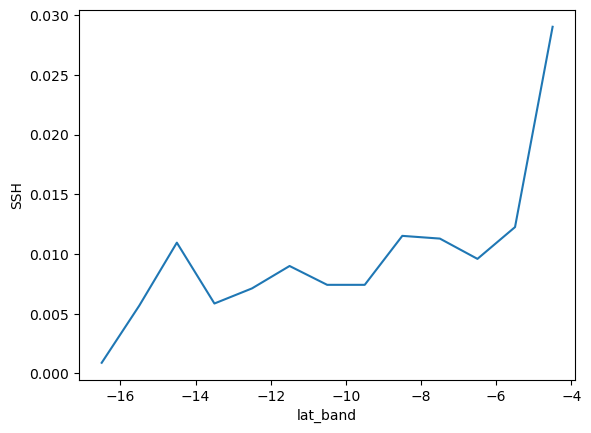

In [25]:
ssh_.mean('time').plot()

In [26]:
lat_centers = np.arange(lat_top_start - 0.5, lat_top_end - 0.5, -1)
Omega = 7.2921e-5
f_ = 2 * Omega * np.sin(np.deg2rad(lat_centers))
f_ = xr.DataArray(f_, dims='lat_band', coords={'lat_band': lat_centers})
f_

<xarray.DataArray (lat_band: 13)> Size: 104B
array([-1.14426314e-05, -1.39783362e-05, -1.65097831e-05, -1.90362009e-05,
       -2.15568201e-05, -2.40708729e-05, -2.65775935e-05, -2.90762183e-05,
       -3.15659862e-05, -3.40461388e-05, -3.65159206e-05, -3.89745792e-05,
       -4.14213659e-05])
Coordinates:
  * lat_band  (lat_band) float64 104B -4.5 -5.5 -6.5 -7.5 ... -14.5 -15.5 -16.5

In [27]:
# d_coast = (1/12)*10*111*1000  # 1 degree of latitude in meters
g = 9.81

# Geostrophic cross-shore velocity from alongshore SSH gradient at the coast.
# u_geo = (g/f) * (dSSH/dy)
# Sign convention for CUTI divergence framework:
#   In SH (f<0), with SSH increasing northward (ssh_>0):
#     u_geo = (g / f_neg) * (positive) = negative → onshore (convergent)
#   This is correct: onshore geostrophic return flow reduces CUTI below U_ek.
u_geo = (g / f_) * (ssh_ / d_coast_)

# Verify: should be negative on average (onshore)
print("Mean u_geo (should be negative):", u_geo.mean().values)

Mean u_geo (should be negative): -0.04074680118604648


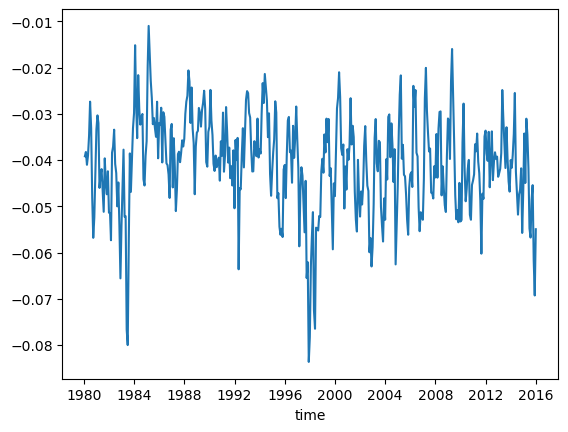

In [28]:
u_geo.mean(dim=('lat_band')).plot()

* The onshore geostrophic flow increased during EN 1997-98

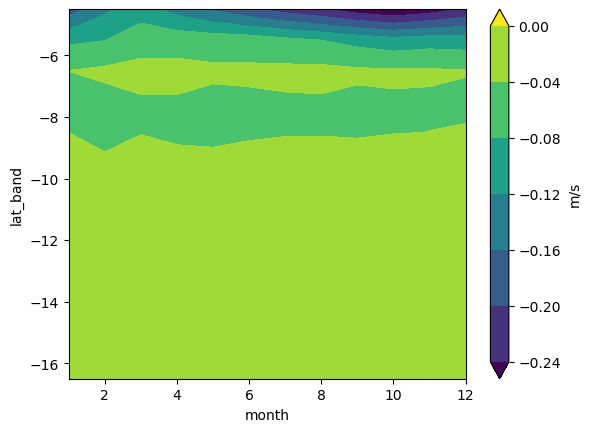

In [29]:
seasonality(u_geo.rename('m/s')).plot.contourf(robust=True)

### MLD

In [30]:
MLD_ds = xr.open_dataset('MLD.nc').compute()
MLD_ds

<xarray.Dataset> Size: 1GB
Dimensions:  (time: 432, lat: 542, lon: 602)
Coordinates:
  * lon      (lon) float64 5kB -119.0 -118.9 -118.8 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 4kB -33.0 -32.93 -32.86 -32.79 ... 9.869 9.951 10.03
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
Data variables:
    MLD      (time, lat, lon) float64 1GB 0.9402 0.9402 1.335 ... nan nan nan

In [31]:
mask_mld = coastal_band_mask(MLD_ds, var='MLD', iterations=10)
MLD_ds = MLD_ds.where(mask_mld).sel(lon=slice(-85,None),lat=slice(-20,-4))
MLD_ds

<xarray.Dataset> Size: 132MB
Dimensions:  (time: 432, lat: 197, lon: 194)
Coordinates:
  * lon      (lon) float64 2kB -84.95 -84.87 -84.78 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 2kB -19.99 -19.92 -19.84 ... -4.245 -4.162 -4.079
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
Data variables:
    MLD      (time, lat, lon) float64 132MB nan nan nan nan ... nan nan nan nan

* Rossby radious in Peru goes from 150 to 50km, then the MLD should be around 100km, following first deformation Rossby radious criteria by Jacox(2018)

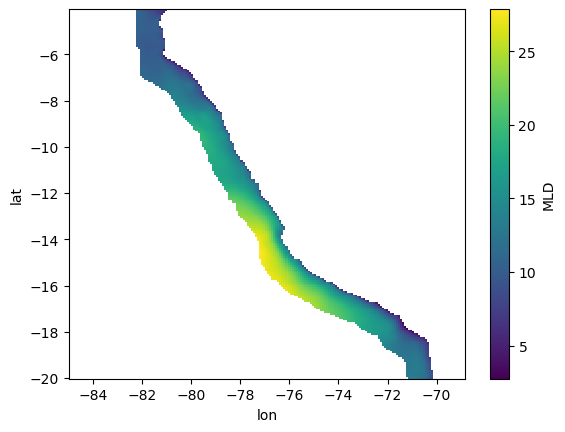

In [32]:
MLD_ds.MLD.std('time').plot()

In [33]:
delta_mld = []

lat_top_start = -4   # first northern edge
lat_top_end   = -17  # last northern edge

for lat_north in tqdm(range(lat_top_start, lat_top_end, -1)):
    lat_south = lat_north - 1
    mld_band = MLD_ds.MLD.sel(lat=slice(lat_south, lat_north)).mean(dim='lat')
    delta_mld.append(mld_band)

mld_ = xr.concat(delta_mld, dim='lat_band')
mld_ = mld_.assign_coords(
    lat_band=np.arange(lat_top_start - 0.5, lat_top_end - 0.5, -1)
)

100%|███████████████████████████████████████████████████████████████████████████████████| 13/13 [00:00<00:00, 215.34it/s]


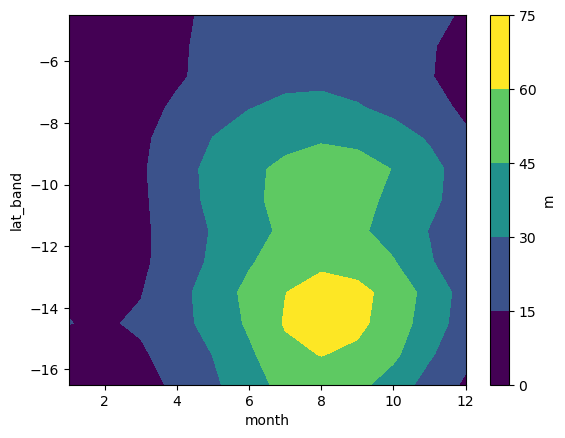

In [34]:
seasonality(mld_.mean(dim=('lon')).rename('m')).plot.contourf()

## $U^{geo}$

Text(0.5, 1.0, '$U^{Geo}$')

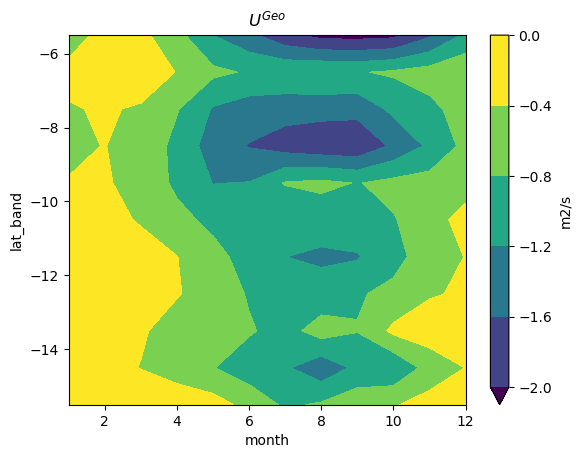

In [35]:
U_geo = (u_geo * mld_)
seasonality((u_geo * mld_).mean(dim='lon')).sel(lat_band=slice(-5,-16)).rename('m2/s').plot.contourf(robust=True)
# seasonality((u_geo * mld_).mean(dim='lon')).rename('m2/s').plot.contourf(robust=True)

plt.title('$U^{Geo}$')

* Negative is onshore 

In [36]:
U_geo.sel(lat_band=slice(-5.5,-16.5))

<xarray.DataArray (lat_band: 12, time: 432, lon: 194)> Size: 8MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]])
Coordinates:
  * lat_band  (lat_band) float64 96B -5.5 -6.5 -7.5 -8.5 ... -14.5 -15.5 -16.5
  * time      (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
  * lon       (lon) float64 2kB -84.95 -84.87 -84.78 ... -69.03 -68.95 -68.87

## CUTI

$CUTI$ = $U^{Ek}$ + $U^{Geo}$

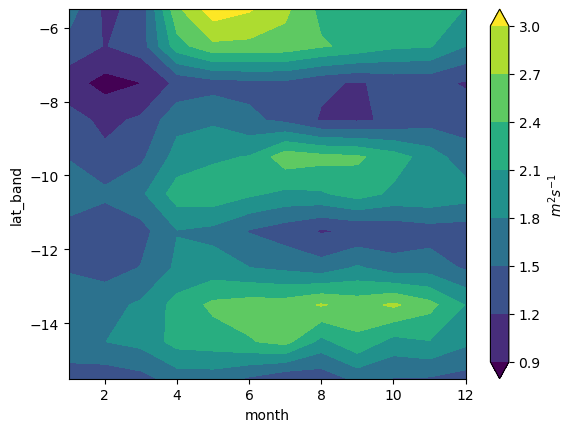

In [37]:
CUTI = (U_ek) + (U_geo)#m2/s

seasonality((CUTI).mean(dim='lon')).sel(lat_band=slice(-5,-16)).rename('$m^2s^{-1}$').plot.contourf(robust=True)

Text(0.5, 1.0, '$CUTI$')

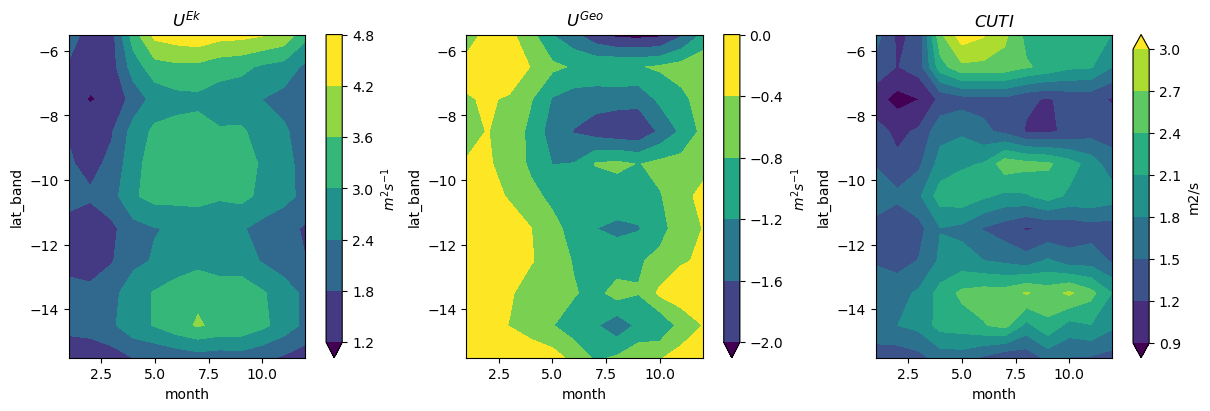

In [38]:
fig,ax = plt.subplots(1,3,figsize=(12,4),constrained_layout=True)

seasonality(U_ek).sel(lat_band=slice(-5,-16)).rename('$m^2s^{-1}$').plot.contourf(
    x='month',robust=True,ax=ax[0])
seasonality(U_geo).mean(dim='lon').sel(lat_band=slice(-5,-16)).rename('$m^2s^{-1}$').plot.contourf(
    x='month',robust=True,ax=ax[1])
seasonality((CUTI).mean(dim='lon')).sel(lat_band=slice(-5,-16)).rename('m2/s').plot.contourf(
    x='month',robust=True,ax=ax[2])

ax[0].set_title('$U^{Ek}$')
ax[1].set_title('$U^{Geo}$')
ax[2].set_title('$CUTI$')

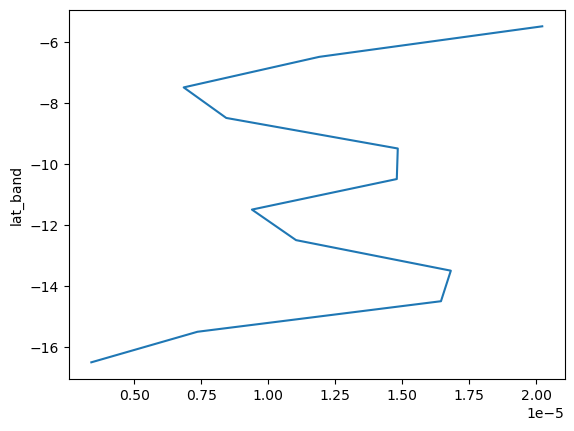

In [39]:
(CUTI/d).mean(dim=('lon','time')).sel(lat_band=slice(-5,-16.5)).plot(y='lat_band')
# (CUTI/d).mean(dim=('lon','time')).plot(y='lat_band')

In [40]:
wmld2 = xr.open_dataset('W_mld_Croco.nc').compute()
wmld2 = wmld2.where(mask).sel(lon=slice(-85,None),lat=slice(-17,-4))
wmld2

<xarray.Dataset> Size: 107MB
Dimensions:  (time: 432, lat: 159, lon: 194)
Coordinates:
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
  * lon      (lon) float64 2kB -84.95 -84.87 -84.78 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 1kB -16.99 -16.91 -16.83 ... -4.245 -4.162 -4.079
Data variables:
    WMLD     (time, lat, lon) float64 107MB nan nan nan nan ... nan nan nan nan

In [41]:
wmld_ = lat_band_mean(wmld2.WMLD,
    lat_top_start=-4,
    lat_top_end=-17,
)

100%|███████████████████████████████████████████████████████████████████████████████████| 13/13 [00:00<00:00, 223.88it/s]


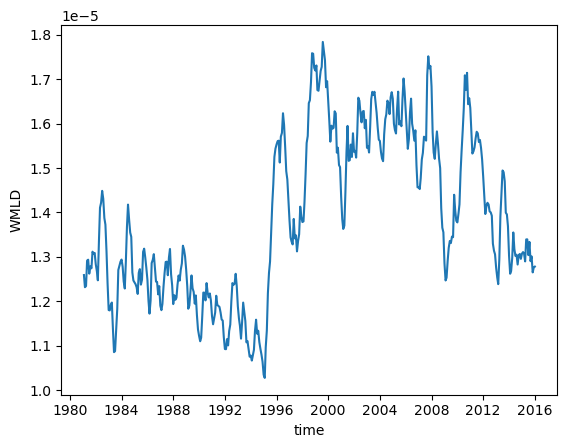

In [42]:
wmld_.sel(lat_band=slice(-5,-16)).mean(dim=('lat_band','lon')).rolling(time=13).mean().plot()

In [43]:
d

<xarray.DataArray 'cross_shore_width' (lat_band: 13)> Size: 104B
array([105458.90064369, 110678.49570305, 174124.19664479, 174557.27090506,
       162664.9712667 , 132518.60065302, 135907.15962886, 148076.86426844,
       150001.13607504, 137427.50132693, 126940.96449613, 194912.35870913,
       263755.17819263])
Coordinates:
  * lat_band  (lat_band) float64 104B -4.5 -5.5 -6.5 -7.5 ... -14.5 -15.5 -16.5

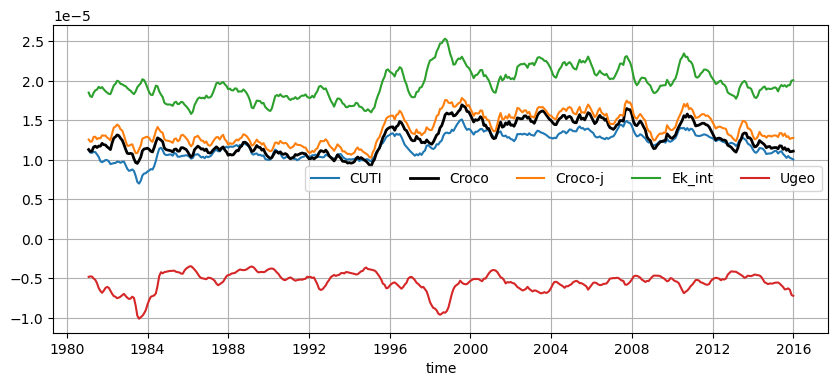

In [44]:
# d = (1/12)*10*111*1000
# d = d_coast.mean('lat_band')
# d = 111*1000

(CUTI/d).sel(lat_band=slice(-5,-16)).mean(dim=('lon','lat_band')).rolling(time=13).mean().plot(label='CUTI',figsize=(10,4))
wmld.mean(dim=('lon','lat')).WMLD.rolling(time=13).mean().rename('m/s').plot(label='Croco',linewidth=2,color='black')
wmld_.sel(lat_band=slice(-5,-16)).mean(dim=('lon','lat_band')).rolling(time=13).mean().rename('m/s').plot(label='Croco-j')

(((U_ek/d)).mean(dim='lat_band')).rolling(time=13).mean().rename('m/s').plot(label='Ek_int')
(U_geo/d).mean(dim=('lat_band','lon')).rolling(time=13).mean().plot(label='Ugeo')

plt.legend(ncols=6,loc='best')
plt.grid()

### Seasonality

In [45]:
wmld

<xarray.Dataset> Size: 90MB
Dimensions:  (time: 432, lat: 134, lon: 194)
Coordinates:
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
  * lon      (lon) float64 2kB -84.95 -84.87 -84.78 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 1kB -15.95 -15.87 -15.79 ... -5.242 -5.159 -5.076
Data variables:
    WMLD     (time, lat, lon) float64 90MB nan nan nan nan ... nan nan nan nan

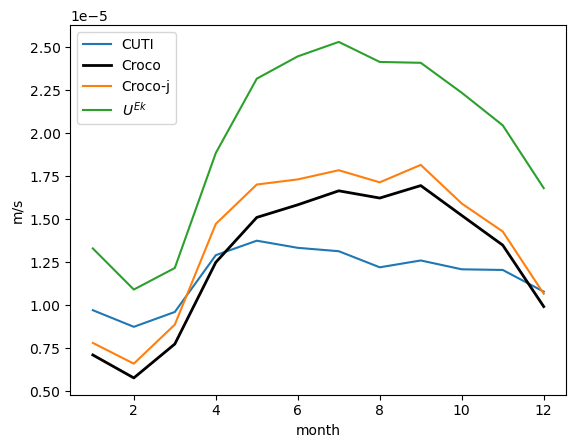

In [46]:
seasonality((CUTI/d)).sel(lat_band=slice(-5,-16)).mean(dim=('lon','lat_band')).plot(label='CUTI')
seasonality(wmld).sel(lat=slice(-16,-5)).mean(dim=('lon','lat')).WMLD.rename('m/s').plot(label='Croco',linewidth=2,color='black')
seasonality(wmld_.sel(lat_band=slice(-5,-16)).mean(dim=('lon','lat_band'))).rename('m/s').plot(label='Croco-j')

(seasonality(U_ek/d)).mean(dim='lat_band').rename('m/s').plot(label='$U^{Ek}$')
# seasonality((U_geo/d).mean(dim=('lat_band','lon'))).plot(label='$U^{Geo}$')
# seasonality((ds.Uekman_Crossshore*-1/d).mean(dim=('lon','lat'))).plot(label='Uekman_crosshore')

plt.legend()

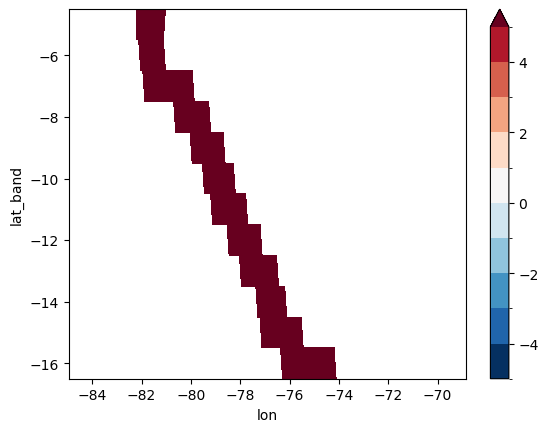

In [47]:
# (wmld*60*60*24).mean('time').WMLD.plot.contourf(robust=True,vmin=-5, vmax=5, cmap='RdBu_r',levels)
(CUTI*60*60*24).mean('time').plot.contourf(robust=True,vmin=-5, vmax=5, cmap='RdBu_r',levels=11)

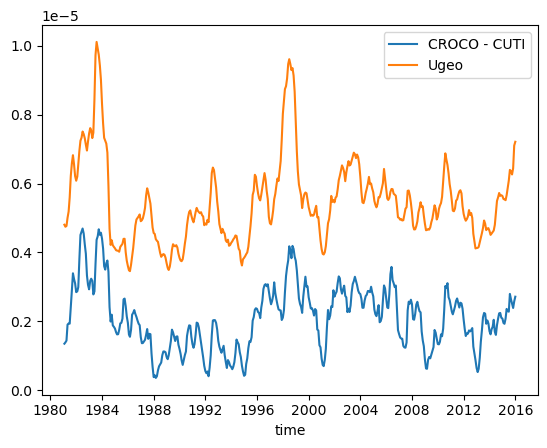

In [48]:
diff = wmld_.sel(lat_band=slice(-5,-16)).mean(dim=('lon','lat_band')) - (CUTI/d).sel(lat_band=slice(-5,-16)).mean(dim=('lon','lat_band'))

diff.rolling(time=13).mean().rename('m/s').plot(label='CROCO - CUTI')
(U_geo*-1/d).mean(dim=('lat_band','lon')).rolling(time=13).mean().plot(label='Ugeo')
plt.legend()

In [49]:
# Compute the ratio to quantify how much of U_GEO explains the offset
ratio = (diff.rolling(time=13).mean() / 
         (U_geo * -1/d).mean(dim=('lat_band','lon')).rolling(time=13).mean())

print(f"Mean ratio CROCO-CUTI / -Ugeo: {float(ratio.mean()):.2f}")

Mean ratio CROCO-CUTI / -Ugeo: 0.38


"Claude said: 
This means:

* 30% of $U^{GEO}$
UGEO is spatially non-uniform → has non-zero divergence → contributes to WMLDW_{MLD}

70% of $U^{GEO}$
is spatially uniform → zero divergence → does not contribute to WMLDW_{MLD}

This is actually a stronger result than I expected — it means the geostrophic flow in the NHUS is predominantly non-uniform spatially, which makes physical sense given the complex coastal geometry, varying shelf width, and mesoscale activity between 5°S and 16°S.
"

Text(0.5, 1.0, 'CUTI')

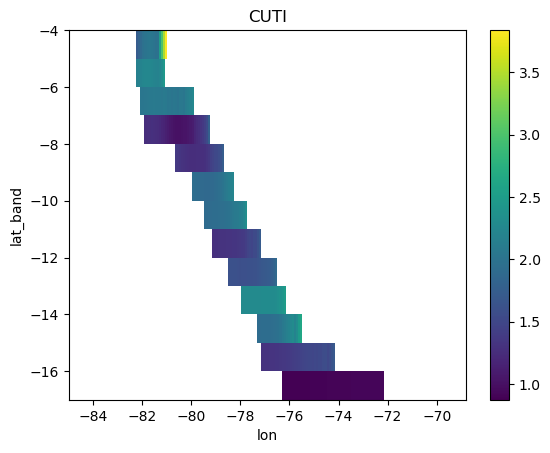

In [50]:
CUTI.mean('time').plot()
plt.title('CUTI')

In [51]:
nitrogen = xr.open_dataset('Nitrogen.nc').compute()
nitrogen

<xarray.Dataset> Size: 2GB
Dimensions:  (time: 432, lat: 542, lon: 602)
Coordinates:
  * lon      (lon) float64 5kB -119.0 -118.9 -118.8 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 4kB -33.0 -32.93 -32.86 -32.79 ... 9.869 9.951 10.03
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
Data variables:
    TN_surf  (time, lat, lon) float32 564MB 0.1585 0.1588 0.1642 ... 0.0 0.0 0.0
    TN_mld   (time, lat, lon) float64 1GB 0.1585 0.1588 0.1642 ... 0.0 0.0 0.0

In [52]:
N = nitrogen.where(mask_mld).sel(lon=slice(-85,None),lat=slice(-17,-4))
N

<xarray.Dataset> Size: 160MB
Dimensions:  (time: 432, lat: 159, lon: 194)
Coordinates:
  * lon      (lon) float64 2kB -84.95 -84.87 -84.78 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 1kB -16.99 -16.91 -16.83 ... -4.245 -4.162 -4.079
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
Data variables:
    TN_surf  (time, lat, lon) float32 53MB nan nan nan nan ... nan nan nan nan
    TN_mld   (time, lat, lon) float64 107MB nan nan nan nan ... nan nan nan nan

In [53]:
N_ = lat_band_mean(N.TN_mld,
    lat_top_start=-4,
    lat_top_end=-17,
)
N_

100%|███████████████████████████████████████████████████████████████████████████████████| 13/13 [00:00<00:00, 213.70it/s]


<xarray.DataArray 'TN_mld' (lat_band: 13, time: 432, lon: 194)> Size: 9MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]])
Coordinates:
  * lon       (lon) float64 2kB -84.95 -84.87 -84.78 ... -69.03 -68.95 -68.87
  * time      (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
  * lat_band  (lat_band) float64 104B -4.5 -5.5 -6.5 -7.5 ... -14.5 -15.5 -16.5

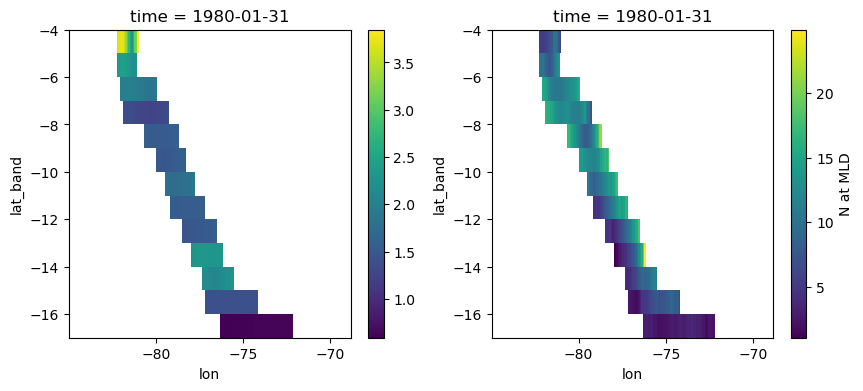

In [54]:
fig,ax = plt.subplots(1,2,figsize=(10,4))
CUTI.isel(time=0).plot(ax=ax[0])
N_.rename('N at MLD').isel(time=0).plot(ax=ax[1])

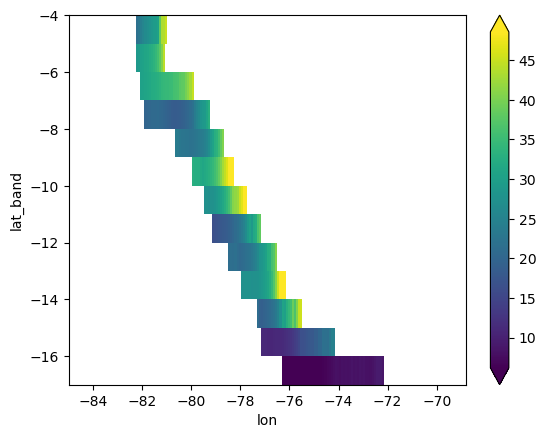

In [55]:
BEUTI = (N_ * CUTI)
(BEUTI).mean('time').plot(robust=True)

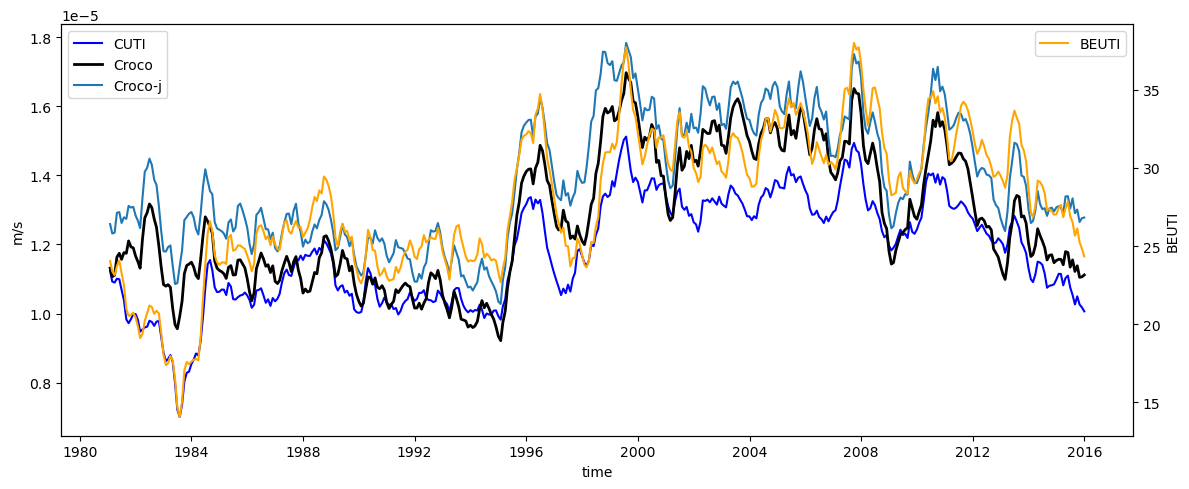

In [56]:
fig, ax1 = plt.subplots(figsize=(12, 5))

# Left axis
(CUTI/d).sel(lat_band=slice(-5,-16)).mean(dim=('lon','lat_band')).rolling(time=13).mean().plot(ax=ax1, label='CUTI', color='Blue')
# (CUTI/d).sel(lat_band=slice(-5,-16)).mean(dim=('lon','lat_band')).rolling(time=13).mean().plot(label='CUTI')

wmld.mean(dim=('lon','lat')).WMLD.rolling(time=13).mean().rename('m/s').plot(ax=ax1, label='Croco', linewidth=2, color='black')
wmld_.sel(lat_band=slice(-5,-16)).mean(dim=('lon','lat_band')).rolling(time=13).mean().rename('m/s').plot(ax=ax1, label='Croco-j')
ax1.set_ylabel('m/s')
ax1.legend(loc='upper left')

# Right axis for BEUTI
ax2 = ax1.twinx()
BEUTI.sel(lat_band=slice(-5,-16)).mean(dim=('lat_band','lon')).rolling(time=13).mean().plot(ax=ax2, label='BEUTI', color='orange')
ax2.set_ylabel('BEUTI')
ax2.legend(loc='upper right')

plt.tight_layout()

In [57]:
N2 = nitrogen.where(mask_mld).sel(lon=slice(-85,None),lat=slice(-16,-5))

Text(0.5, 1.0, 'Nitrogen Cycle')

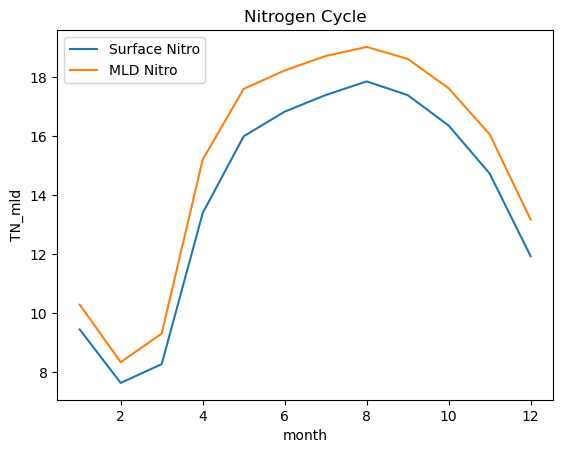

In [58]:
seasonality(N2.TN_surf).mean(dim=('lat','lon')).plot(label='Surface Nitro')
seasonality(N2.TN_mld).mean(dim=('lat','lon')).plot(label='MLD Nitro')
plt.legend()
plt.title('Nitrogen Cycle')

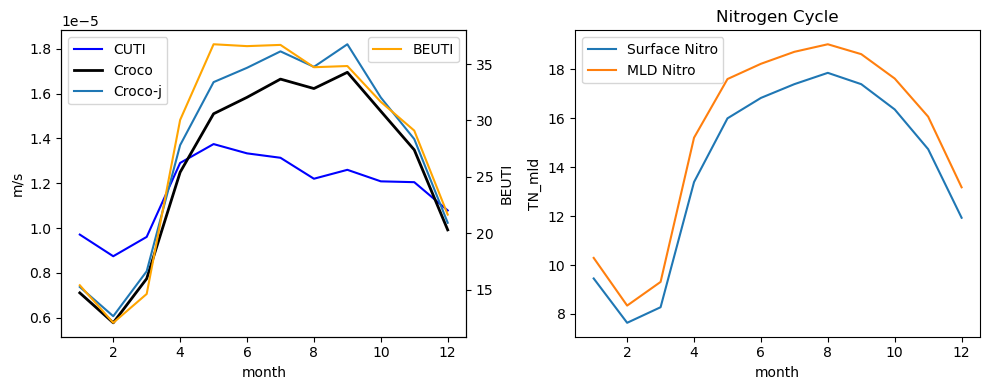

In [59]:
fig, (ax1, ax3) = plt.subplots(1, 2, figsize=(10, 4), sharex=True)

# --- Top panel ---
seasonality((CUTI/d).sel(lat_band=slice(-5,-16)).mean(dim=('lon','lat_band'))).plot(ax=ax1, label='CUTI', color='blue')
seasonality(wmld.mean(dim=('lon','lat')).WMLD).rename('m/s').plot(ax=ax1, label='Croco', linewidth=2, color='black')
seasonality(wmld_.mean(dim=('lon','lat_band'))).rename('m/s').plot(ax=ax1, label='Croco-j')
ax1.set_ylabel('m/s')
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
seasonality(BEUTI.sel(lat_band=slice(-5,-16)).mean(dim=('lat_band','lon'))).plot(ax=ax2, label='BEUTI', color='orange')
ax2.set_ylabel('BEUTI')
ax2.legend(loc='upper right')

# --- Bottom panel ---
seasonality(N2.TN_surf).mean(dim=('lat','lon')).plot(ax=ax3, label='Surface Nitro')
seasonality(N2.TN_mld).mean(dim=('lat','lon')).plot(ax=ax3, label='MLD Nitro')
ax3.legend()
ax3.set_title('Nitrogen Cycle')

plt.tight_layout()

* Nitrogen input follows the upwelling season, BEUTI amplifies CUTI in seasonal scales

In [60]:
wmld_ = wmld_.rename('Croco_j')
wmld_

<xarray.DataArray 'Croco_j' (lat_band: 13, time: 432, lon: 194)> Size: 9MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]])
Coordinates:
  * time      (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
  * lon       (lon) float64 2kB -84.95 -84.87 -84.78 ... -69.03 -68.95 -68.87
  * lat_band  (lat_band) float64 104B -4.5 -5.5 -6.5 -7.5 ... -14.5 -15.5 -16.5

In [61]:
CUTI = CUTI.to_dataset(name='CUTI')
# CUTI

In [62]:
CUTI['BEUTI'] = BEUTI
CUTI['UGEO'] = U_geo
CUTI['u_geo'] = u_geo
CUTI['U_ek'] = U_ek
CUTI['N_mld'] = N_
CUTI['CROCO_j'] = wmld_

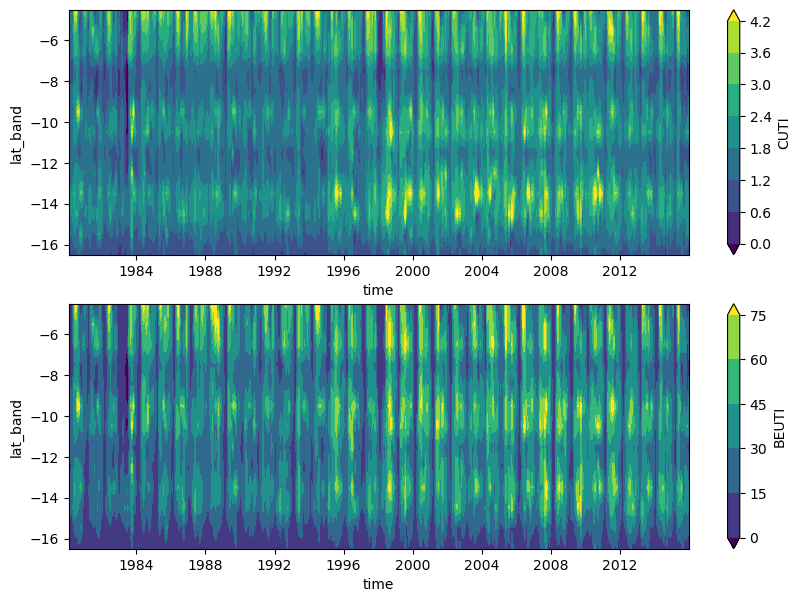

In [63]:
fig,ax = plt.subplots(2,1,figsize=(10,7))
CUTI.CUTI.mean(dim='lon').plot.contourf(robust=True,ax=ax[0])
CUTI.BEUTI.mean(dim='lon').plot.contourf(robust=True,ax=ax[1])

In [64]:
CUTI['cross_shore_distance'] = d
CUTI

<xarray.Dataset> Size: 44MB
Dimensions:               (time: 432, lat_band: 13, lon: 194)
Coordinates:
  * time                  (time) datetime64[ns] 3kB 1980-01-31 ... 2015-12-31
  * lat_band              (lat_band) float64 104B -4.5 -5.5 -6.5 ... -15.5 -16.5
  * lon                   (lon) float64 2kB -84.95 -84.87 ... -68.95 -68.87
Data variables:
    CUTI                  (lat_band, time, lon) float64 9MB nan nan ... nan nan
    BEUTI                 (lat_band, time, lon) float64 9MB nan nan ... nan nan
    UGEO                  (lat_band, time, lon) float64 9MB nan nan ... nan nan
    u_geo                 (lat_band, time) float64 45kB -0.2529 ... -0.003756
    U_ek                  (lat_band, time) float64 45kB 4.941 3.208 ... 0.7994
    N_mld                 (lat_band, time, lon) float64 9MB nan nan ... nan nan
    CROCO_j               (lat_band, time, lon) float64 9MB nan nan ... nan nan
    cross_shore_distance  (lat_band) float64 104B 1.055e+05 ... 2.638e+05

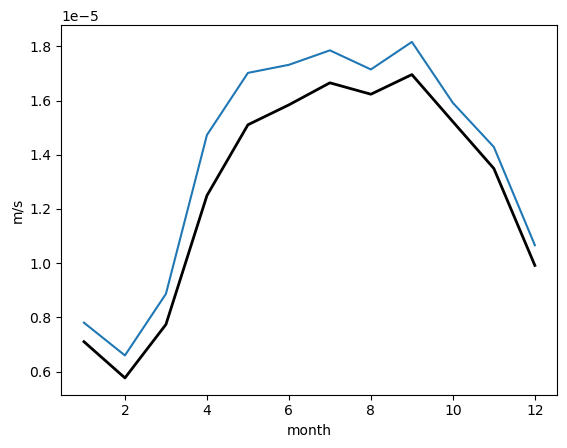

In [65]:
seasonality(CUTI).CROCO_j.sel(lat_band=slice(-5,-16)).mean(dim=('lat_band','lon')).plot()
seasonality(wmld).sel(lat=slice(-16,-5)).mean(dim=('lon','lat')).WMLD.rename('m/s').plot(label='Croco',linewidth=2,color='black')


In [66]:
# CUTI.to_netcdf('latitudinal/CUTI_BEUTI_components.nc')